In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

TRAIN_DIR = '/content/drive/MyDrive/AI and Machine Learning/Assessment/Sign Language Detection-20260416T180914Z-3-001/Sign Language Detection/Train'
TEST_DIR  = '/content/drive/MyDrive/AI and Machine Learning/Assessment/Sign Language Detection-20260416T180914Z-3-001/Sign Language Detection/Test'
import os
print('Train classes found:', len(os.listdir(TRAIN_DIR)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train classes found: 38


In [ ]:
import shutil, os

# Delete the incomplete copy
LOCAL_DIR = '/content/sign_language_local'
if os.path.exists(LOCAL_DIR):
    shutil.rmtree(LOCAL_DIR)
    print('Deleted incomplete copy')

# Redo the copy from scratch
SOURCE ='/content/drive/MyDrive/AI and Machine Learning/Assessment/Sign Language Detection-20260416T180914Z-3-001/Sign Language Detection'

print('Copying fresh from Drive (this takes 3-5 min)...')
shutil.copytree(SOURCE, LOCAL_DIR)
print('Done!')

# Verify
TRAIN_DIR = f'{LOCAL_DIR}/Train'
TEST_DIR  = f'{LOCAL_DIR}/Test'
class_count = len(os.listdir(TRAIN_DIR))
print(f'TRAIN_DIR: {TRAIN_DIR}')
print(f'Train classes found: {class_count}')

if class_count == 38:
    print('All 38 classes copied successfully.')
else:
    print(f'Expected 38 but got {class_count}.')

Copying fresh from Drive (this takes 3-5 min)...
Done!
TRAIN_DIR: /content/sign_language_local/Train
Train classes found: 38
All 38 classes copied successfully.


In [ ]:
# Standard Python libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — for splitting data and evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# TensorFlow and Keras — our deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Check GPU
print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', 'YES ')

TensorFlow version: 2.20.0
GPU available: YES 


In [ ]:
import pickle

SAVE_DIR = '/content/drive/MyDrive/AI and Machine Learning/Assessment/VisionTask Models'

baseline_model = keras.models.load_model(f'{SAVE_DIR}/baseline_cnn.keras')
deeper_model = keras.models.load_model(f'{SAVE_DIR}/deeper_cnn_adam.keras')
deeper_sgd = keras.models.load_model(f'{SAVE_DIR}/deeper_cnn_sgd.keras')
ablation_model = keras.models.load_model(f'{SAVE_DIR}/ablation_no_dropout.keras')
tl_model = keras.models.load_model(f'{SAVE_DIR}/mobilenetv2_tl.keras')

def load_hist(name):
    with open(f'{SAVE_DIR}/{name}.pkl', 'rb') as f:
        return type('obj', (), {'history': pickle.load(f)})()

history_baseline = load_hist('baseline_history')
history_deeper = load_hist('deeper_history')
history_sgd = load_hist('sgd_history')
history_ablation = load_hist('ablation_history')
history_tl1 = load_hist('tl_phase1_history')
history_tl2 = load_hist('tl_phase2_history')

print('All models + histories loaded!')

All models + histories loaded!


In [ ]:
# 1.1 Dataset Overview
# Count how many images are in each class folder

classes = sorted(os.listdir(TRAIN_DIR), key=lambda x: int(x))
num_classes = len(classes)
class_counts = {}
total_images = 0

for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[cls] = count
    total_images += count

print('=' * 50)
print(f'Dataset: Bengali Sign Language Detection')
print(f'Total Classes: {num_classes}')
print(f'Total Training Images: {total_images}')
print(f'Average Images per Class: {total_images // num_classes}')
print(f'Min Images in a Class: {min(class_counts.values())} (Class {min(class_counts, key=class_counts.get)})')
print(f'Max Images in a Class: {max(class_counts.values())} (Class {max(class_counts, key=class_counts.get)})')
print('=' * 50)|

Dataset: Bengali Sign Language Detection
Total Classes: 38
Total Training Images: 10792
Average Images per Class: 284
Min Images in a Class: 239 (Class 4)
Max Images in a Class: 293 (Class 22)


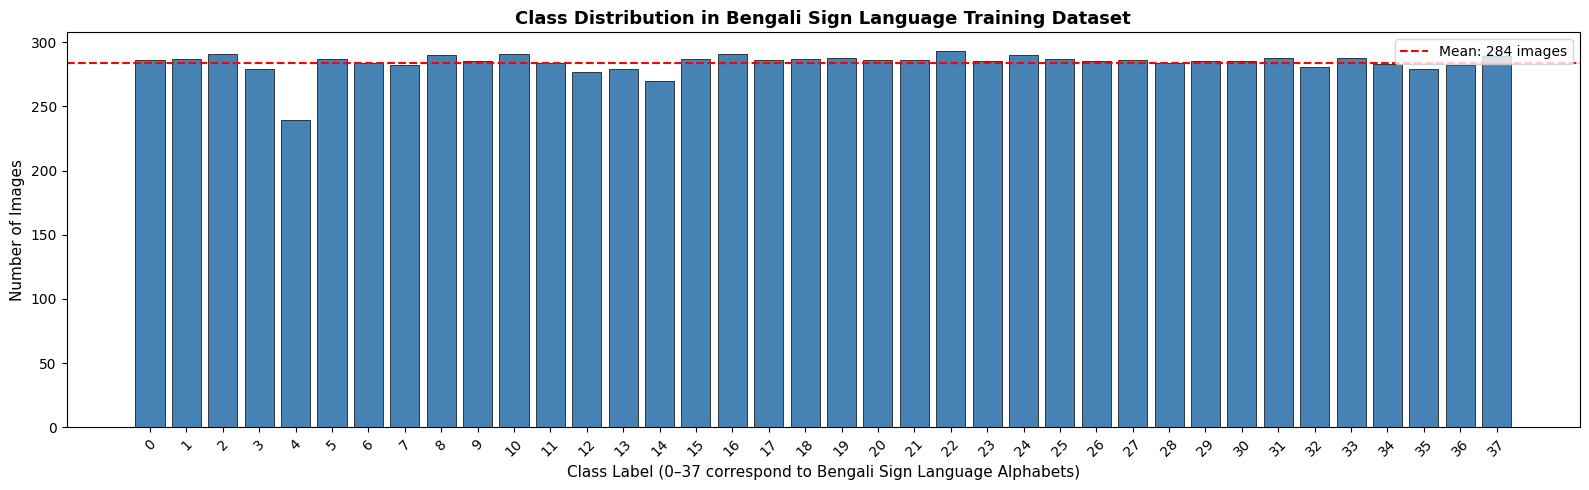

Observation: The dataset is well-balanced — each class has approximately 284–298 images.
This means the model will not be biased towards any particular sign.


In [ ]:
# 1.2 Class Distribution Bar Chart
# This chart shows how many images each class has.
# We want all bars to be roughly equal height (balanced dataset).

plt.figure(figsize=(16, 5))
bars = plt.bar(classes, [class_counts[c] for c in classes], color='steelblue', edgecolor='black', linewidth=0.5)
plt.axhline(y=total_images/num_classes, color='red', linestyle='--', label=f'Mean: {total_images//num_classes} images')
plt.xlabel('Class Label (0–37 correspond to Bengali Sign Language Alphabets)', fontsize=11)
plt.ylabel('Number of Images', fontsize=11)
plt.title('Class Distribution in Bengali Sign Language Training Dataset', fontsize=13, fontweight='bold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('Observation: The dataset is well-balanced — each class has approximately 284–298 images.')
print('This means the model will not be biased towards any particular sign.')

In [ ]:
# Scan and remove all corrupted images from the dataset
from PIL import Image

corrupted = []
print('Scanning for corrupted images...')

for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for img_file in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_file)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupted.append(img_path)

print(f'Found {len(corrupted)} corrupted images')

for path in corrupted:
    os.remove(path)

print('Cleanup complete!')

Scanning for corrupted images...
Found 0 corrupted images
Cleanup complete!


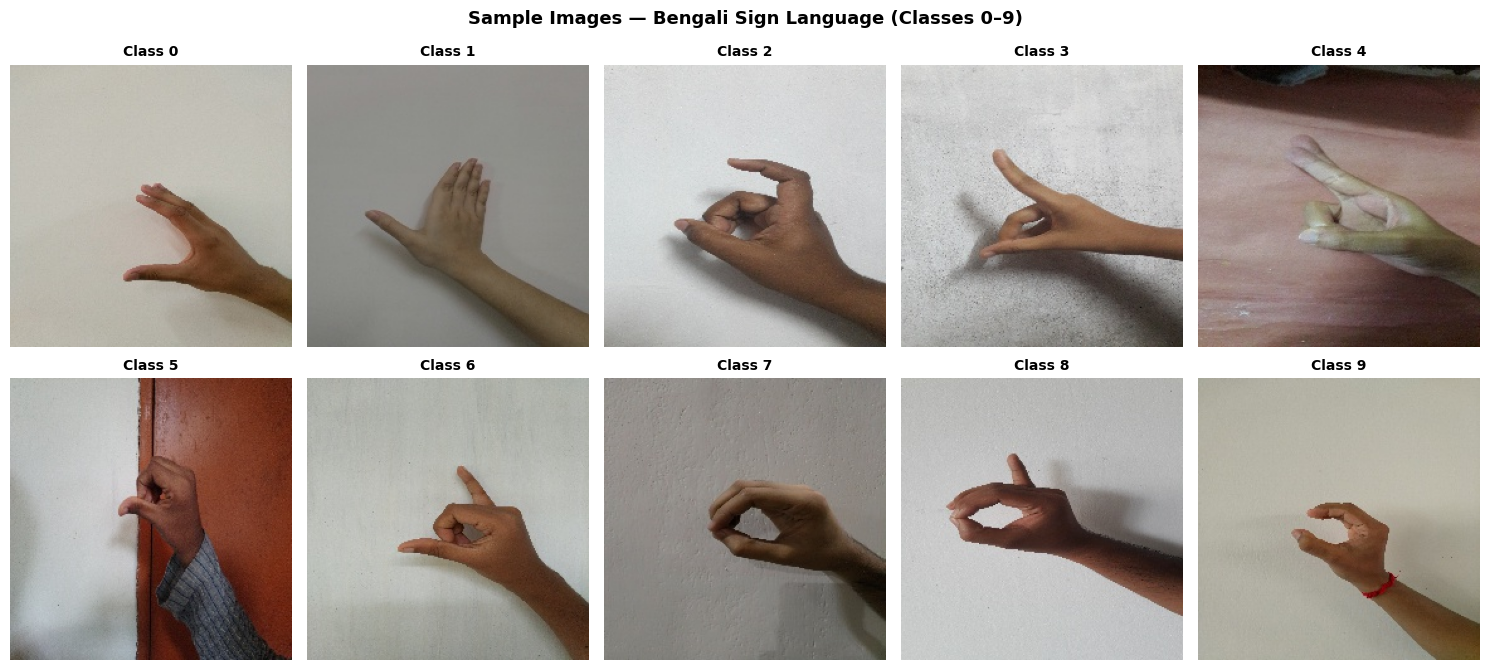

In [ ]:
# 1.3 Sample Images from Each Class
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for idx, cls in enumerate(classes[:10]):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[idx].imshow(img)
    axes[idx].set_title(f'Class {cls}', fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Images — Bengali Sign Language (Classes 0–9)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

In [ ]:
# 1.4 Image Properties
# Check the size and colour mode of the images

from PIL import Image as PILImage
sample_path = os.path.join(TRAIN_DIR, classes[0], os.listdir(os.path.join(TRAIN_DIR, classes[0]))[0])
sample_img = PILImage.open(sample_path)

print(f'Image size (width x height): {sample_img.size}')
print(f'Colour mode: {sample_img.mode}  ← RGB means 3 colour channels (Red, Green, Blue)')
print(f'Image shape as array: {np.array(sample_img).shape}  ← (height, width, channels)')
print()
print('All images are 224×224 pixels in RGB format.')
print('This is perfect — no resizing needed, and it matches what transfer learning models expect.')

Image size (width x height): (224, 224)
Colour mode: RGB  ← RGB means 3 colour channels (Red, Green, Blue)
Image shape as array: (224, 224, 3)  ← (height, width, channels)

All images are 224×224 pixels in RGB format.
This is perfect — no resizing needed, and it matches what transfer learning models expect.


In [ ]:
# ── Configuration constants
IMG_SIZE    = (224, 224)   # Width and height to resize all images to
BATCH_SIZE  = 32           # How many images to process at once
NUM_CLASSES = 38           # Number of sign language categories
SEED        = 42           # Random seed for reproducibility

# ── Training Data Generator (with augmentation)
# Augmentation = creating slightly different versions of images
# This helps the model learn to recognise signs from different angles/positions
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalise pixel values from 0-255 to 0-1
    validation_split=0.2,      # Use 20% of data for validation
    rotation_range=15,         # Randomly rotate images up to ±15 degrees
    zoom_range=0.15,           # Randomly zoom in/out by up to 15%
    width_shift_range=0.1,     # Randomly shift image horizontally
    height_shift_range=0.1,    # Randomly shift image vertically
    horizontal_flip=False,     # Don't flip — hand signs are not symmetric!
    brightness_range=[0.8, 1.2], # Random brightness to handle different lighting
    fill_mode='nearest'        # Fill empty pixels with nearest pixel value
)

# ── Validation Data Generator (NO augmentation — just normalisation) ──
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# ── Load Training Set
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # One-hot encoding for multi-class
    subset='training',
    seed=SEED
)

# ── Load Validation Set
val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False  # Don't shuffle validation — we need consistent ordering for evaluation
)

print(f'Training samples: {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Split: {train_generator.samples/(train_generator.samples+val_generator.samples)*100:.0f}% train, {val_generator.samples/(train_generator.samples+val_generator.samples)*100:.0f}% validation')

Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Training samples: 8648
Validation samples: 2144
Split: 80% train, 20% validation


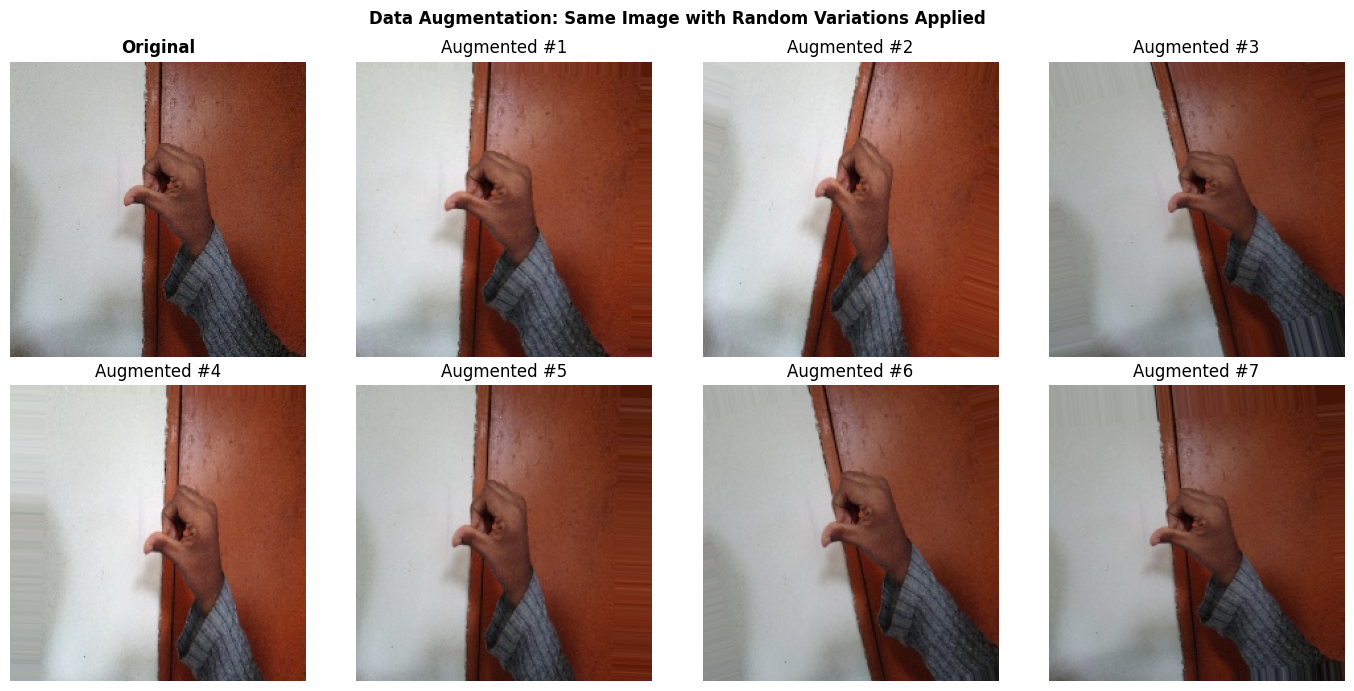

These variations help the model learn to recognise signs from different angles, zoom levels, and lighting.


In [ ]:
# ── Visualise Augmented Images
# Show what augmentation does — the same image with random variations applied

from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load one sample image
sample_cls_path = os.path.join(TRAIN_DIR, classes[5])
sample_img_path = os.path.join(sample_cls_path, os.listdir(sample_cls_path)[0])
sample = load_img(sample_img_path, target_size=IMG_SIZE)
sample_arr = img_to_array(sample)
sample_arr = sample_arr.reshape((1,) + sample_arr.shape)

# Apply augmentation 8 times and show results
aug_gen = ImageDataGenerator(
    rotation_range=15, zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
axes[0].imshow(sample.resize(IMG_SIZE))
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i, batch in enumerate(aug_gen.flow(sample_arr, batch_size=1), start=1):
    if i >= 8: break
    axes[i].imshow(batch[0].astype('uint8'))
    axes[i].set_title(f'Augmented #{i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation: Same Image with Random Variations Applied', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()
print('These variations help the model learn to recognise signs from different angles, zoom levels, and lighting.')

In [ ]:
# ── Build Baseline CNN Model
# Architecture: 3 Conv+Pool blocks → Flatten → 3 Dense layers → Output

def build_baseline_cnn(num_classes, input_shape=(224, 224, 3)):
    """
    Builds a simple baseline CNN with:
    - 3 Convolutional layers (each followed by MaxPooling)
    - 3 Fully Connected (Dense) layers
    - 1 Output layer with softmax activation
    """
    model = models.Sequential([
        # ── Input layer
        layers.Input(shape=input_shape),

        # ── Block 1: First Conv + Pool
        # 32 filters of size 3x3 — detects basic features like edges
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),   # Shrinks image from 224x224 to 112x112

        # ── Block 2: Second Conv + Pool
        # 64 filters — detects more complex features like curves and corners
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),   # Shrinks to 56x56

        # ── Block 3: Third Conv + Pool
        # 128 filters — detects high-level features like hand shapes
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),   # Shrinks to 28x28

        # ── Flatten
        # Converts 3D feature maps into a 1D vector for Dense layers
        layers.Flatten(),

        # ── Dense Layer 1
        layers.Dense(512, activation='relu'),

        # ── Dense Layer 2
        layers.Dense(256, activation='relu'),

        # ── Dense Layer 3
        layers.Dense(128, activation='relu'),

        # ── Output Layer
        # 38 neurons (one per class), softmax outputs a probability for each class
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,643,110 (197.00 MB)

 Trainable params: 51,643,110 (197.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Compile the Baseline Model
# Compiling = telling the model HOW to learn
# - optimizer: Adam — automatically adjusts learning speed (good default choice)
# - loss: categorical_crossentropy — standard loss for multi-class classification
# - metrics: accuracy — what % of images we classify correctly

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks
# Callbacks are automatic actions taken during training:
# - EarlyStopping: stops training if validation accuracy stops improving
#   (prevents overfitting and wasting time)
# - ReduceLROnPlateau: reduces learning rate if training stalls

callbacks_baseline = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('Baseline model compiled and ready to train!')

Baseline model compiled and ready to train!


In [ ]:
# Train the Baseline Model
# This is where the model actually learns from the data.
# Each 'epoch' = one full pass through the training data.

NUM_CLASSES = 38

def build_baseline_cnn(num_classes, input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Flatten with one more pool to keep size manageable
        layers.MaxPooling2D((2, 2)),  # Extra pooling to shrink before Flatten
        layers.Flatten(),

        # 3 Dense layers (assignment requirement)
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),

        layers.Dense(32, activation='relu'),

        # Output
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         1,254 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,317,894 (12.66 MB)

 Trainable params: 3,317,062 (12.65 MB)

 Non-trainable params: 832 (3.25 KB)

In [ ]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]
print('Compiled!')

Compiled!


In [ ]:
class PercentLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f'Epoch {epoch+1} | Train Acc: {logs["accuracy"]*100:.2f}% | Val Acc: {logs["val_accuracy"]*100:.2f}%')

import time
print('Training Baseline CNN...')
start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_baseline + [PercentLogger()],
    verbose=1
)

baseline_training_time = time.time() - start_time
print(f'\nBaseline training complete! Time taken: {baseline_training_time/60:.1f} minutes')
print(f'Final Train Accuracy: {history_baseline.history["accuracy"][-1]*100:.2f}%')
print(f'Final Val Accuracy:   {history_baseline.history["val_accuracy"][-1]*100:.2f}%')

Training Baseline CNN...
Epoch 1/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.0363 - loss: 3.7639Epoch 1 | Train Acc: 4.75% | Val Acc: 2.52%
271/271 ━━━━━━━━━━━━━━━━━━━━ 161s 548ms/step - accuracy: 0.0475 - loss: 3.6641 - val_accuracy: 0.0252 - val_loss: 8.5732 - learning_rate: 5.0000e-04
Epoch 2/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.0967 - loss: 3.4413Epoch 2 | Train Acc: 10.94% | Val Acc: 9.61%
271/271 ━━━━━━━━━━━━━━━━━━━━ 128s 474ms/step - accuracy: 0.1094 - loss: 3.3741 - val_accuracy: 0.0961 - val_loss: 3.3891 - learning_rate: 5.0000e-04
Epoch 3/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.1660 - loss: 3.1198Epoch 3 | Train Acc: 18.36% | Val Acc: 20.24%
271/271 ━━━━━━━━━━━━━━━━━━━━ 130s 478ms/step - accuracy: 0.1836 - loss: 3.0222 - val_accuracy: 0.2024 - val_loss: 2.8582 - learning_rate: 5.0000e-04
Epoch 4/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.2326 - loss: 2.7358Epoch 4 | Train Acc: 24.62% | Val Acc: 27.71%

In [ ]:
import os, pickle

SAVE_DIR = '/content/drive/MyDrive/AI and Machine Learning/Assessment/VisionTask Models'
os.makedirs(SAVE_DIR, exist_ok=True)

baseline_model.save(f'{SAVE_DIR}/baseline_cnn.keras')
with open(f'{SAVE_DIR}/baseline_history.pkl', 'wb') as f:
    pickle.dump(history_baseline.history, f)

print('  Baseline saved to VisionTask Models!')
print(f'   Final Train Accuracy: {history_baseline.history["accuracy"][-1]*100:.2f}%')
print(f'   Final Val Accuracy:   {history_baseline.history["val_accuracy"][-1]*100:.2f}%')

  Baseline saved to VisionTask Models!
   Final Train Accuracy: 79.13%
   Final Val Accuracy:   73.93%


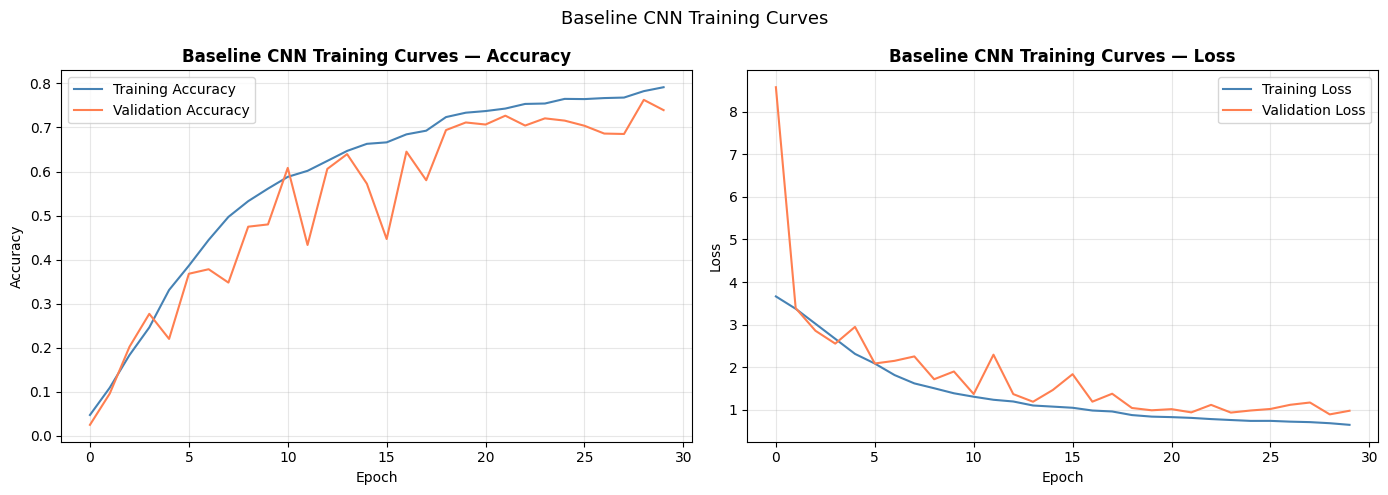

In [ ]:
# ── Plot Training Curves for Baseline Model
# These plots show how the model improved over each epoch.
# - Training curve: performance on training data
# - Validation curve: performance on unseen data
# If training >> validation → overfitting!

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy', color='steelblue')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='coral')
    ax1.set_title(f'{title} — Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss', color='steelblue')
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='coral')
    ax2.set_title(f'{title} — Loss', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150)
    plt.show()

plot_history(history_baseline, 'Baseline CNN Training Curves')

In [ ]:
# Evaluate Baseline Model
# Evaluate on the validation set and get detailed metrics

val_generator.reset()  # Reset to beginning
val_loss, val_acc = baseline_model.evaluate(val_generator, verbose=0)
print(f'Baseline CNN — Validation Accuracy: {val_acc*100:.2f}%')
print(f'Baseline CNN — Validation Loss:     {val_loss:.4f}')

# Get predictions for classification report
val_generator.reset()
y_pred_probs = baseline_model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)   # Predicted class index
y_true = val_generator.classes             # True class index

print('\nClassification Report (Baseline CNN):')
print(classification_report(y_true, y_pred, target_names=[f'Class {c}' for c in classes]))

Baseline CNN — Validation Accuracy: 76.26%
Baseline CNN — Validation Loss:     0.8959
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step

Classification Report (Baseline CNN):
              precision    recall  f1-score   support

     Class 0       0.46      0.82      0.59        57
     Class 1       0.83      0.77      0.80        57
     Class 2       0.69      0.83      0.75        58
     Class 3       0.59      0.86      0.70        56
     Class 4       0.83      0.78      0.80        55
     Class 5       0.75      0.76      0.76        55
     Class 6       0.84      0.67      0.74        54
     Class 7       0.95      0.70      0.81        57
     Class 8       0.94      0.84      0.89        58
     Class 9       0.98      0.72      0.83        57
    Class 10       0.59      0.77      0.67        57
    Class 11       0.90      0.47      0.62        57
    Class 12       0.98      0.86      0.92        58
    Class 13       0.83      0.77      0.80        57
    Class 14       0.78 

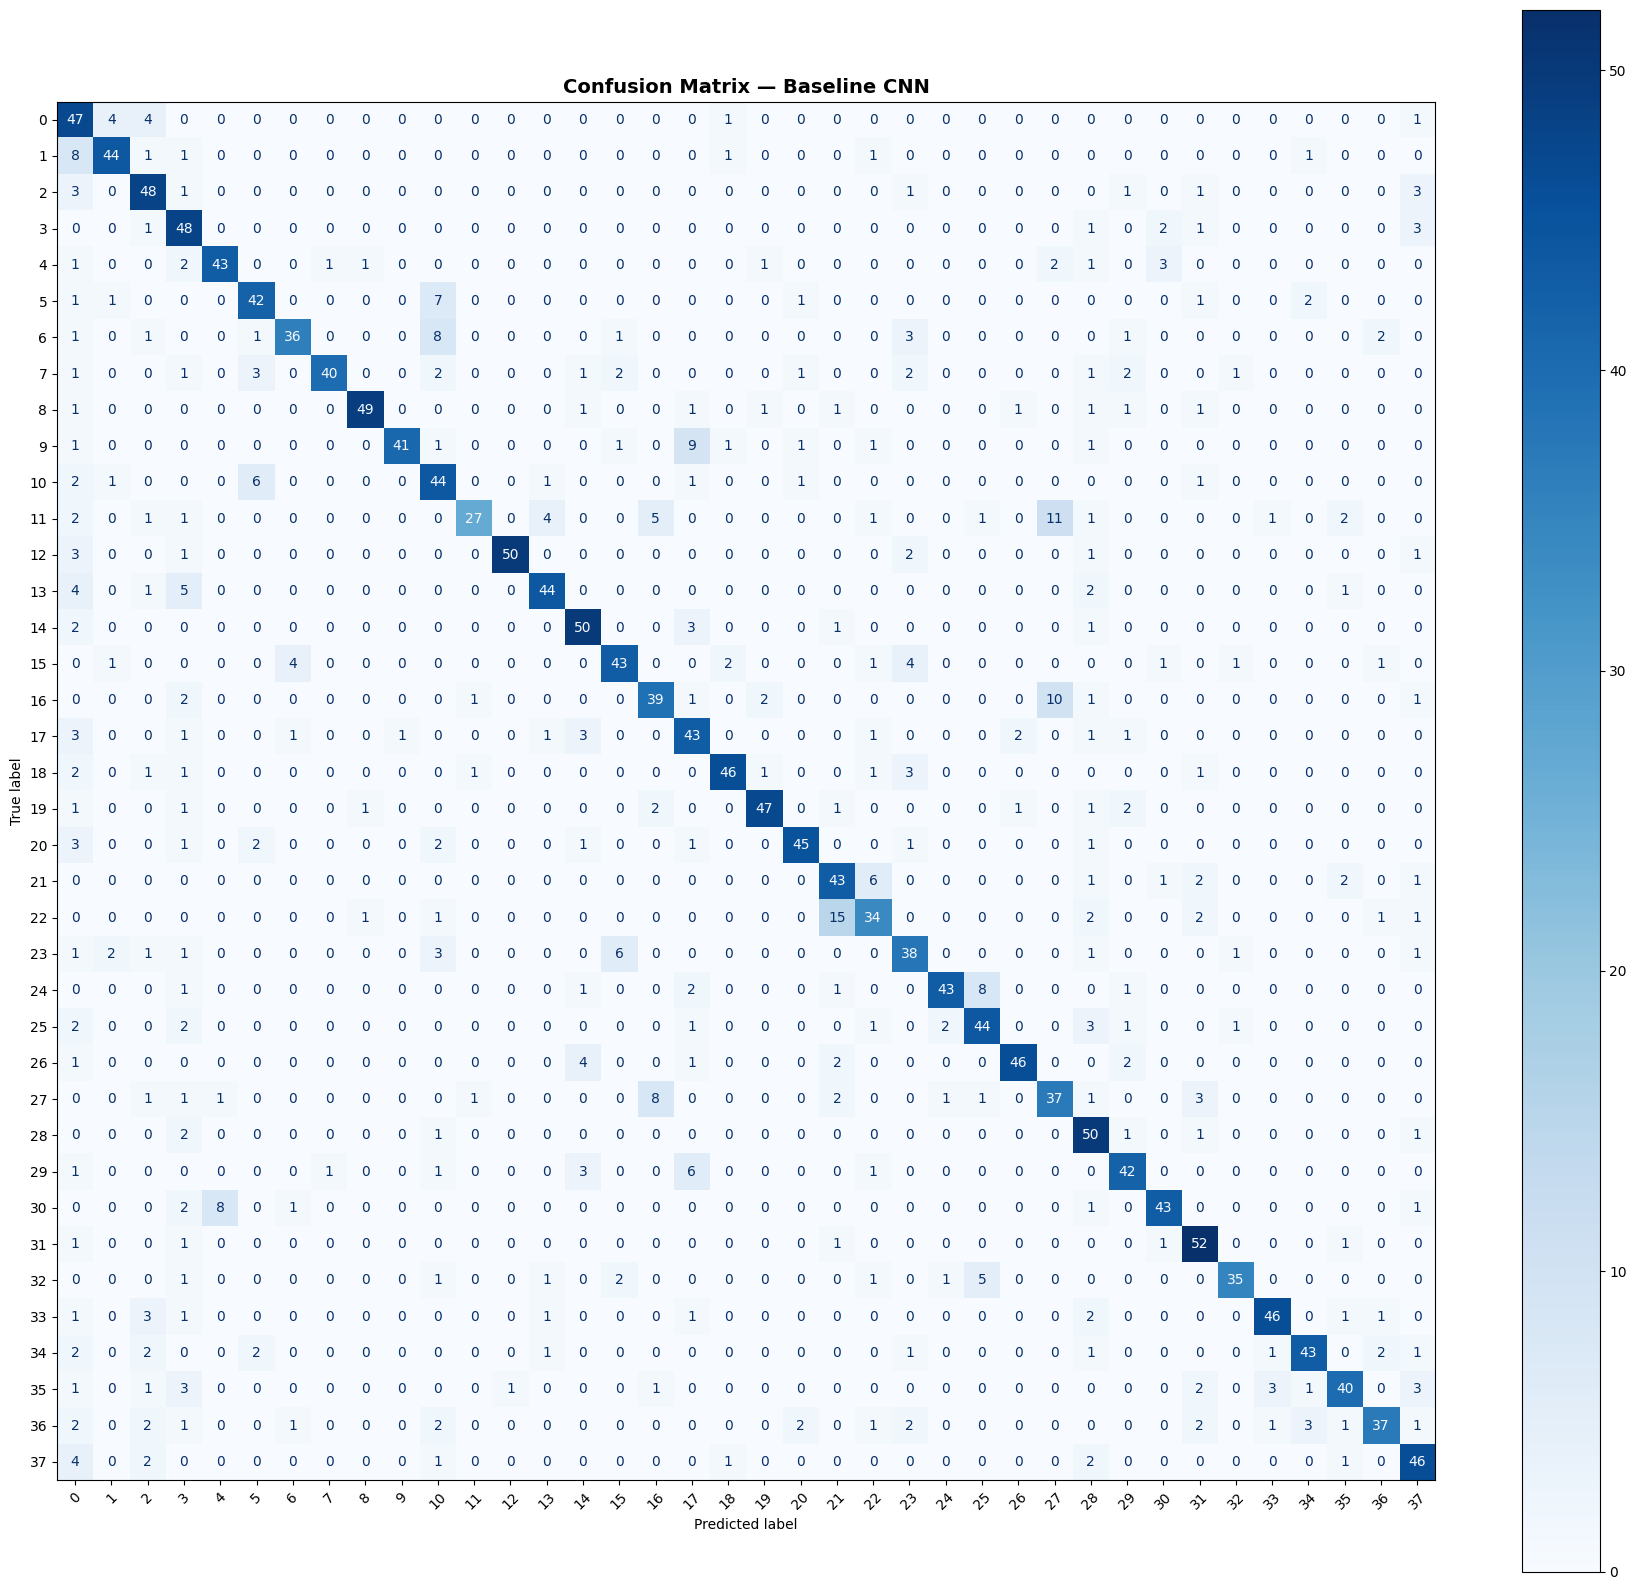

In [ ]:
# Confusion Matrix for Baseline
# A confusion matrix shows WHICH classes are being confused with which.
# Perfect model = bright diagonal line, dark everywhere else.

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — Baseline CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150)
plt.show()

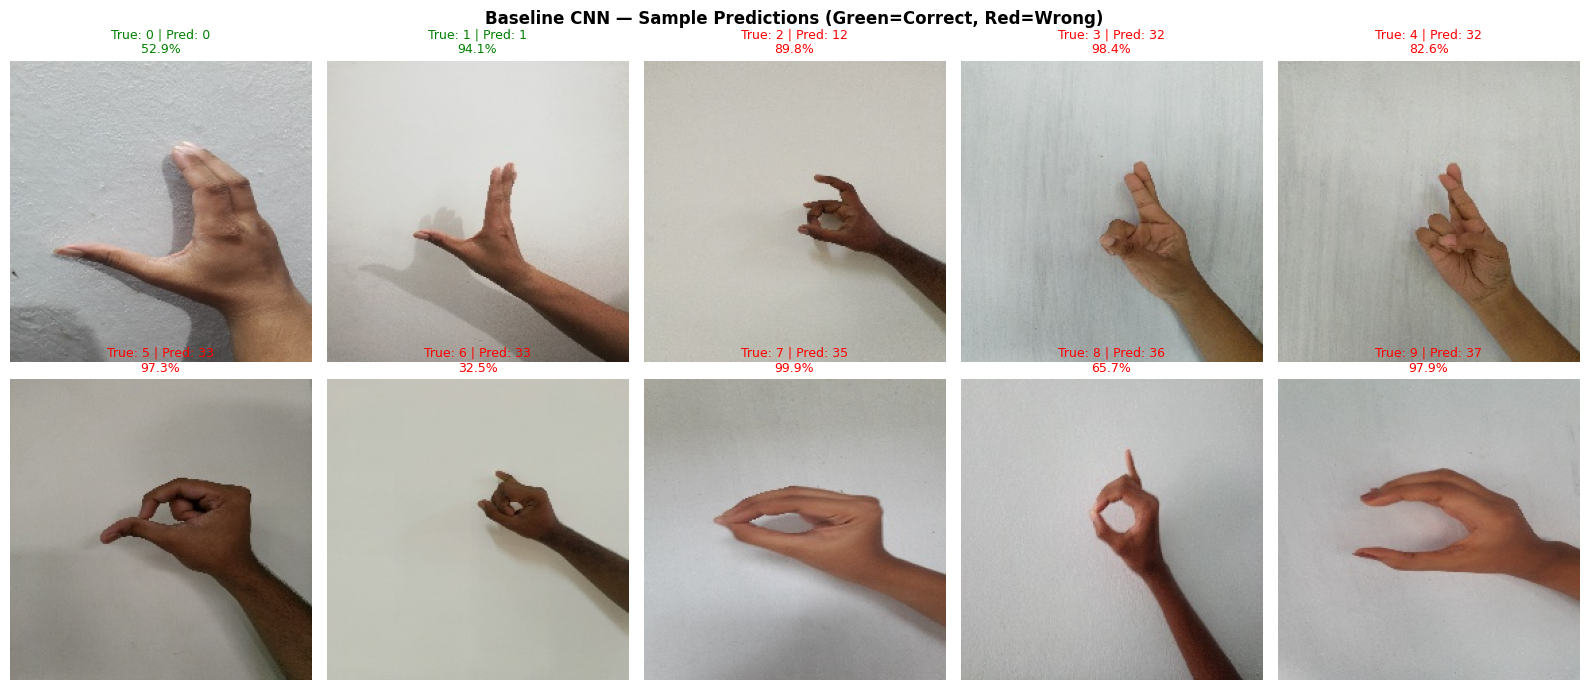

In [ ]:
# ── Inference on Sample Images ────────────────────────────────────────
# Let's visually check the model's predictions on specific images

from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_sample(model, img_path, true_label=None):
    img = load_img(img_path, target_size=IMG_SIZE)
    arr = img_to_array(img) / 255.0
    arr = np.expand_dims(arr, 0)
    pred = model.predict(arr, verbose=0)
    pred_class = np.argmax(pred)
    confidence = pred[0][pred_class] * 100
    return img, pred_class, confidence

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for idx, cls in enumerate(classes[:10]):
    cls_path = os.path.join(TRAIN_DIR, cls)
    # Pick from last few images (ones the model saw less during training)
    img_files = os.listdir(cls_path)
    img_path = os.path.join(cls_path, img_files[-1])
    img, pred_class, conf = predict_sample(baseline_model, img_path)
    correct = str(pred_class) == cls
    color = 'green' if correct else 'red'
    axes[idx].imshow(img)
    axes[idx].set_title(f'True: {cls} | Pred: {pred_class}\n{conf:.1f}%', color=color, fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Baseline CNN — Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150)
plt.show()

In [ ]:
# ── Build Deeper CNN Model

def build_deeper_cnn(num_classes, input_shape=(224, 224, 3)):
    """
    Deeper CNN with:
    - 7 Convolutional layers (vs 3 in baseline)
    - BatchNormalization after each Conv layer
    - Dropout for regularisation
    - GlobalAveragePooling instead of Flatten (reduces parameters)
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # ── Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),  # Normalises outputs → more stable training
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),         # 25% of neurons randomly switched off

        # ── Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Global Average Pooling
        # Replaces Flatten — takes average of each feature map.
        # Significantly reduces parameters and helps prevent overfitting.
        layers.GlobalAveragePooling2D(),

        # ── Dense Layers
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),           # 50% dropout before output

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),

        # ── Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

deeper_model = build_deeper_cnn(NUM_CLASSES)
deeper_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 859,718 (3.28 MB)

 Trainable params: 857,286 (3.27 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
# ── Compile and Train Deeper Model (with Adam)

deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deeper = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('Training Deeper CNN with Adam optimizer...')
start_time = time.time()

history_deeper = deeper_model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks_deeper + [PercentLogger()],
    verbose=1
)

deeper_training_time = time.time() - start_time
print(f'\nDeeper CNN training complete! Time taken: {deeper_training_time/60:.1f} minutes')
print(f'Final Train Accuracy: {history_deeper.history["accuracy"][-1]*100:.2f}%')
print(f'Final Val Accuracy:   {history_deeper.history["val_accuracy"][-1]*100:.2f}%')

Training Deeper CNN with Adam optimizer...
Epoch 1/40
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.0302 - loss: 4.4943Epoch 1 | Train Acc: 3.23% | Val Acc: 2.80%
271/271 ━━━━━━━━━━━━━━━━━━━━ 172s 545ms/step - accuracy: 0.0323 - loss: 4.3091 - val_accuracy: 0.0280 - val_loss: 3.8438 - learning_rate: 0.0010
Epoch 2/40
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.0360 - loss: 3.9624Epoch 2 | Train Acc: 3.71% | Val Acc: 2.99%
271/271 ━━━━━━━━━━━━━━━━━━━━ 131s 483ms/step - accuracy: 0.0371 - loss: 3.9016 - val_accuracy: 0.0299 - val_loss: 4.0234 - learning_rate: 0.0010
Epoch 3/40
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.0496 - loss: 3.6688Epoch 3 | Train Acc: 5.77% | Val Acc: 4.52%
271/271 ━━━━━━━━━━━━━━━━━━━━ 132s 485ms/step - accuracy: 0.0577 - loss: 3.5699 - val_accuracy: 0.0452 - val_loss: 4.0884 - learning_rate: 0.0010
Epoch 4/40
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.1099 - loss: 3.2761Epoch 4 | Train Acc: 11.77% | Val Acc: 2.8

In [ ]:
import os, pickle

SAVE_DIR = '/content/drive/MyDrive/AI and Machine Learning/Assessment/VisionTask Models'
os.makedirs(SAVE_DIR, exist_ok=True)

deeper_model.save(f'{SAVE_DIR}/deeper_cnn_adam.keras')
with open(f'{SAVE_DIR}/deeper_history.pkl', 'wb') as f:
    pickle.dump(history_deeper.history, f)

print(' Deeper model (Adam) saved to VisionTask Models!')
print(f'   Final Train Accuracy: {history_deeper.history["accuracy"][-1]*100:.2f}%')
print(f'   Final Val Accuracy:   {history_deeper.history["val_accuracy"][-1]*100:.2f}%')

 Deeper model (Adam) saved to VisionTask Models!
   Final Train Accuracy: 91.54%
   Final Val Accuracy:   86.43%


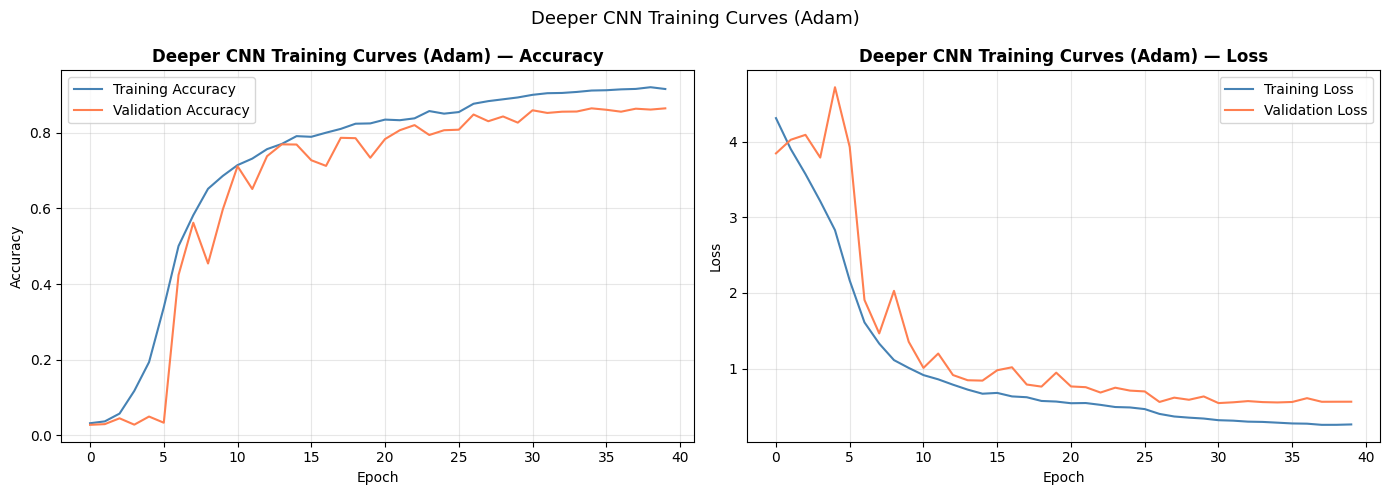

Deeper CNN (Adam) — Validation Accuracy: 86.43%
Deeper CNN (Adam) — Validation Loss:     0.5536
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step

Classification Report (Deeper CNN — Adam):
              precision    recall  f1-score   support

     Class 0       0.81      0.84      0.83        57
     Class 1       0.89      0.82      0.85        57
     Class 2       0.69      0.86      0.77        58
     Class 3       0.94      0.86      0.90        56
     Class 4       0.91      0.87      0.89        55
     Class 5       0.89      0.87      0.88        55
     Class 6       0.71      0.74      0.73        54
     Class 7       1.00      0.88      0.93        57
     Class 8       0.88      0.90      0.89        58
     Class 9       1.00      0.91      0.95        57
    Class 10       0.83      0.88      0.85        57
    Class 11       1.00      0.81      0.89        57
    Class 12       0.72      0.91      0.80        58
    Class 13       0.94      0.84      0.89        57
    Class

In [ ]:
# ── Plot and Evaluate Deeper Model

plot_history(history_deeper, 'Deeper CNN Training Curves (Adam)')

val_generator.reset()
val_loss_d, val_acc_d = deeper_model.evaluate(val_generator, verbose=0)
print(f'Deeper CNN (Adam) — Validation Accuracy: {val_acc_d*100:.2f}%')
print(f'Deeper CNN (Adam) — Validation Loss:     {val_loss_d:.4f}')

val_generator.reset()
y_pred_deeper = np.argmax(deeper_model.predict(val_generator, verbose=1), axis=1)
print('\nClassification Report (Deeper CNN — Adam):')
print(classification_report(y_true, y_pred_deeper, target_names=[f'Class {c}' for c in classes]))

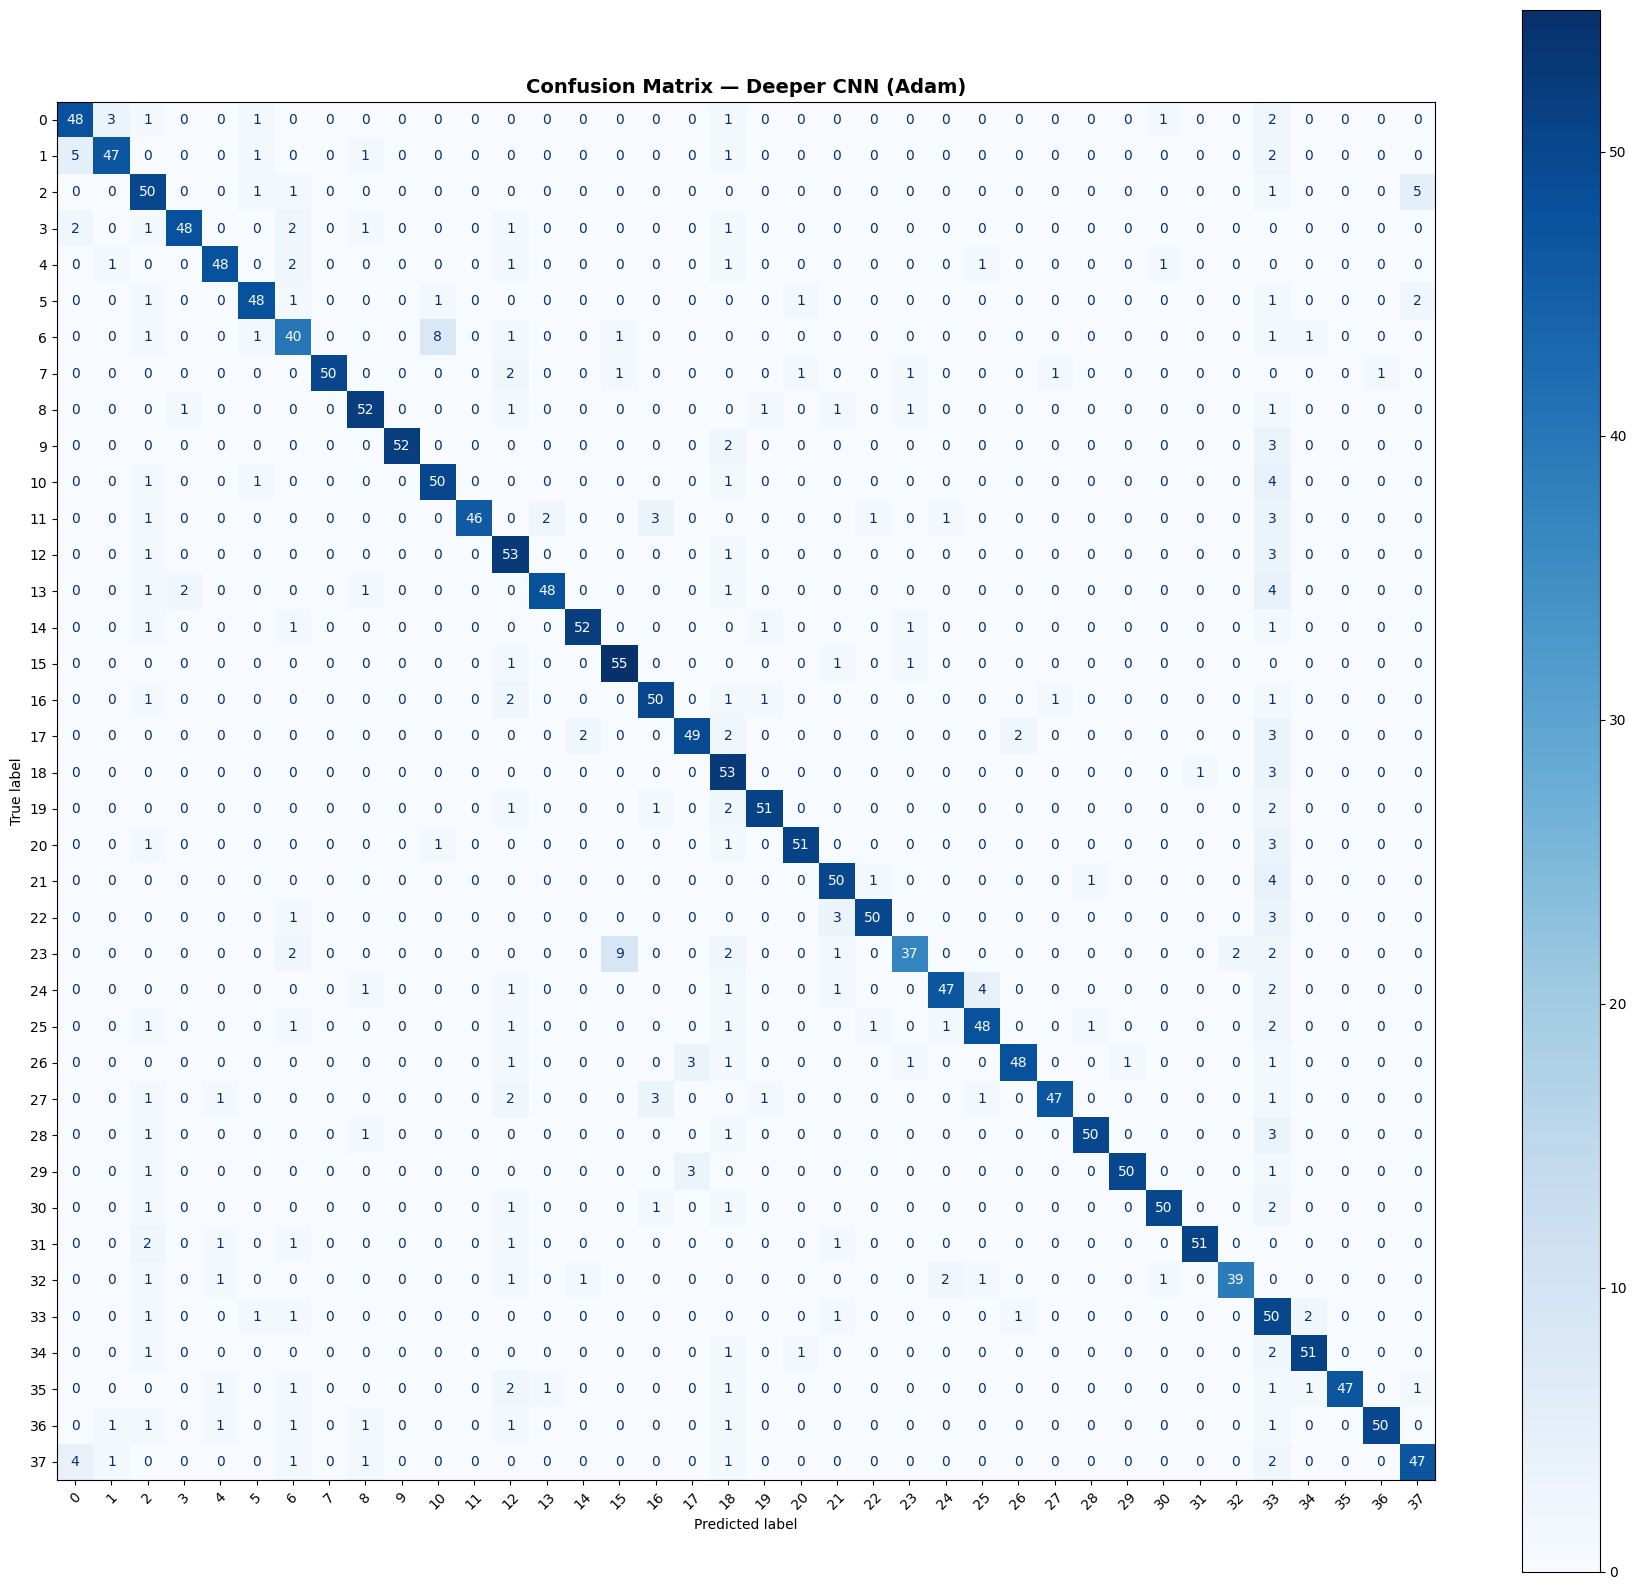

In [ ]:
# ── Confusion Matrix for Deeper Model

cm_deeper = confusion_matrix(y_true, y_pred_deeper)
fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_deeper, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — Deeper CNN (Adam)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_deeper.png', dpi=150)
plt.show()

In [ ]:
# ── Train Deeper Model with SGD
# Same architecture, different optimizer

deeper_sgd = build_deeper_cnn(NUM_CLASSES)
deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('Training Deeper CNN with SGD optimizer...')
start_time = time.time()

history_sgd = deeper_sgd.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks_sgd + [PercentLogger()],
    verbose=1
)

sgd_training_time = time.time() - start_time
print(f'SGD training time: {sgd_training_time/60:.1f} minutes')
print(f'Final Train Accuracy: {history_sgd.history["accuracy"][-1]*100:.2f}%')
print(f'Final Val Accuracy:   {history_sgd.history["val_accuracy"][-1]*100:.2f}%')

Training Deeper CNN with SGD optimizer...
Epoch 1/40
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.0302 - loss: 4.4708Epoch 1 | Train Acc: 3.08% | Val Acc: 2.57%
271/271 ━━━━━━━━━━━━━━━━━━━━ 157s 534ms/step - accuracy: 0.0308 - loss: 4.2532 - val_accuracy: 0.0257 - val_loss: 3.6934 - learning_rate: 0.0100
Epoch 2/40
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.0321 - loss: 3.8220Epoch 2 | Train Acc: 3.63% | Val Acc: 2.52%
271/271 ━━━━━━━━━━━━━━━━━━━━ 134s 493ms/step - accuracy: 0.0363 - loss: 3.7802 - val_accuracy: 0.0252 - val_loss: 3.6777 - learning_rate: 0.0100
Epoch 3/40
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.0440 - loss: 3.6603Epoch 3 | Train Acc: 4.74% | Val Acc: 2.99%
271/271 ━━━━━━━━━━━━━━━━━━━━ 135s 498ms/step - accuracy: 0.0474 - loss: 3.6253 - val_accuracy: 0.0299 - val_loss: 3.6710 - learning_rate: 0.0100
Epoch 4/40
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.0540 - loss: 3.5731Epoch 4 | Train Acc: 5.87% | Val Acc: 5.50%

In [ ]:
import os, pickle

SAVE_DIR = '/content/drive/MyDrive/AI and Machine Learning/Assessment/VisionTask Models'
deeper_sgd.save(f'{SAVE_DIR}/deeper_cnn_sgd.keras')

with open(f'{SAVE_DIR}/sgd_history.pkl', 'wb') as f:
    pickle.dump(history_sgd.history, f)

print('SGD saved!')
print(f'Final Train Accuracy: {history_sgd.history["accuracy"][-1]*100:.2f}%')
print(f'Final Val Accuracy: {history_sgd.history["val_accuracy"][-1]*100:.2f}%')

SGD saved!
Final Train Accuracy: 83.97%
Final Val Accuracy: 79.24%


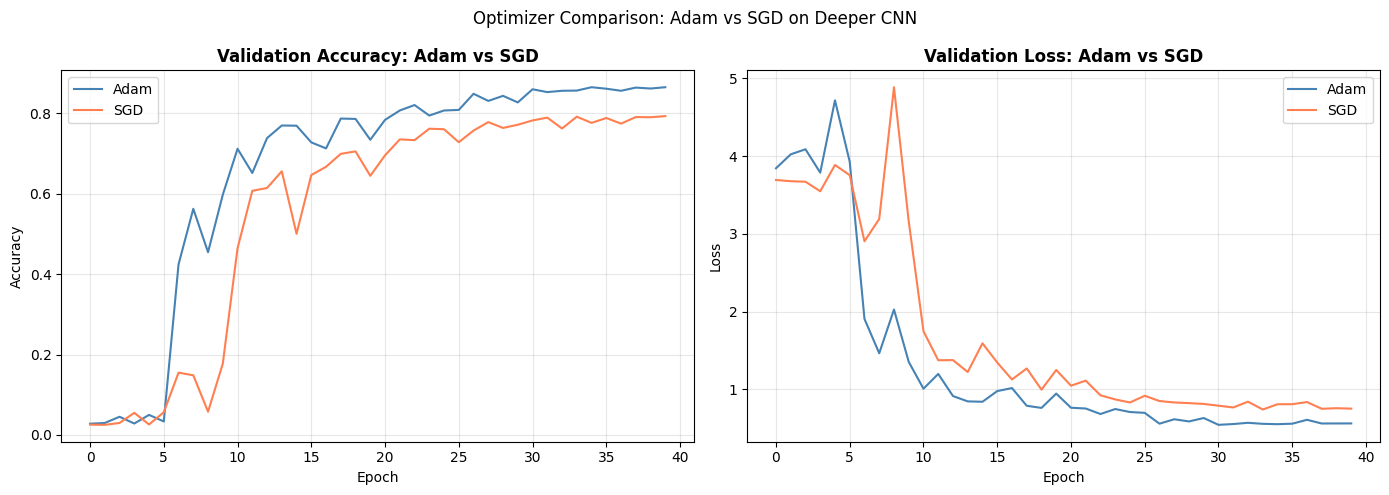

Deeper CNN (SGD)  — Validation Accuracy: 79.24%
Deeper CNN (Adam) — Validation Accuracy: 86.43%


In [ ]:
# ── Optimizer Comparison Plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_deeper.history['val_accuracy'], label='Adam', color='steelblue')
ax1.plot(history_sgd.history['val_accuracy'], label='SGD', color='coral')
ax1.set_title('Validation Accuracy: Adam vs SGD', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history_deeper.history['val_loss'], label='Adam', color='steelblue')
ax2.plot(history_sgd.history['val_loss'], label='SGD', color='coral')
ax2.set_title('Validation Loss: Adam vs SGD', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison: Adam vs SGD on Deeper CNN', fontsize=12)
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()

# Evaluate SGD model
val_generator.reset()
_, val_acc_sgd = deeper_sgd.evaluate(val_generator, verbose=0)
print(f'Deeper CNN (SGD)  — Validation Accuracy: {val_acc_sgd*100:.2f}%')
print(f'Deeper CNN (Adam) — Validation Accuracy: {val_acc_d*100:.2f}%')

In [ ]:
# ── Ablation Study: Remove Dropout
# We remove Dropout from the deeper model to see how it affects performance
# This demonstrates WHY regularisation is important

def build_deeper_no_dropout(num_classes, input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        # NO DROPOUT HERE
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        # NO DROPOUT HERE
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

ablation_model = build_deeper_no_dropout(NUM_CLASSES)
ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training Ablation Model (No Dropout)...')
history_ablation = ablation_model.fit(
    train_generator,
    epochs=20,  # Fewer epochs for comparison
    validation_data=val_generator,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)],
    verbose=1
)

In [ ]:
import os, pickle

SAVE_DIR = '/content/drive/MyDrive/AI and Machine Learning/Assessment/VisionTask Models'
ablation_model.save(f'{SAVE_DIR}/ablation_no_dropout.keras')

with open(f'{SAVE_DIR}/ablation_history.pkl', 'wb') as f:
    pickle.dump(history_ablation.history, f)

print('Ablation saved!')
print(f'Final Train Accuracy: {history_ablation.history["accuracy"][-1]*100:.2f}%')
print(f'Final Val Accuracy:   {history_ablation.history["val_accuracy"][-1]*100:.2f}%')

Ablation saved!
Final Train Accuracy: 85.16%
Final Val Accuracy:   71.92%


In [ ]:
NUM_CLASSES = 38
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False
)

# Also for transfer learning
tl_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)
tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False
)

classes = sorted(os.listdir(TRAIN_DIR), key=lambda x: int(x))
print(f'Generators ready! Val samples: {val_generator.samples}')

Found 2144 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Generators ready! Val samples: 2144


In [ ]:
# Evaluate all loaded models to get accuracy variables
print('Evaluating all models ')

val_generator.reset()
_, val_acc = baseline_model.evaluate(val_generator, verbose=0)
print(f'Baseline:        {val_acc*100:.2f}%')

val_generator.reset()
_, val_acc_d = deeper_model.evaluate(val_generator, verbose=0)
print(f'Deeper (Adam):   {val_acc_d*100:.2f}%')

val_generator.reset()
_, val_acc_sgd = deeper_sgd.evaluate(val_generator, verbose=0)
print(f'Deeper (SGD):    {val_acc_sgd*100:.2f}%')

val_generator.reset()
_, acc_ablation = ablation_model.evaluate(val_generator, verbose=0)
print(f'Ablation:        {acc_ablation*100:.2f}%')

tl_val_gen.reset()
_, tl_acc = tl_model.evaluate(tl_val_gen, verbose=0)
print(f'Transfer Learning: {tl_acc*100:.2f}%')

print('\n All accuracy variables now set!')

Evaluating all models 
Baseline:        76.26%
Deeper (Adam):   86.43%
Deeper (SGD):    79.24%
Ablation:        71.92%
Transfer Learning: 91.51%

 All accuracy variables now set!


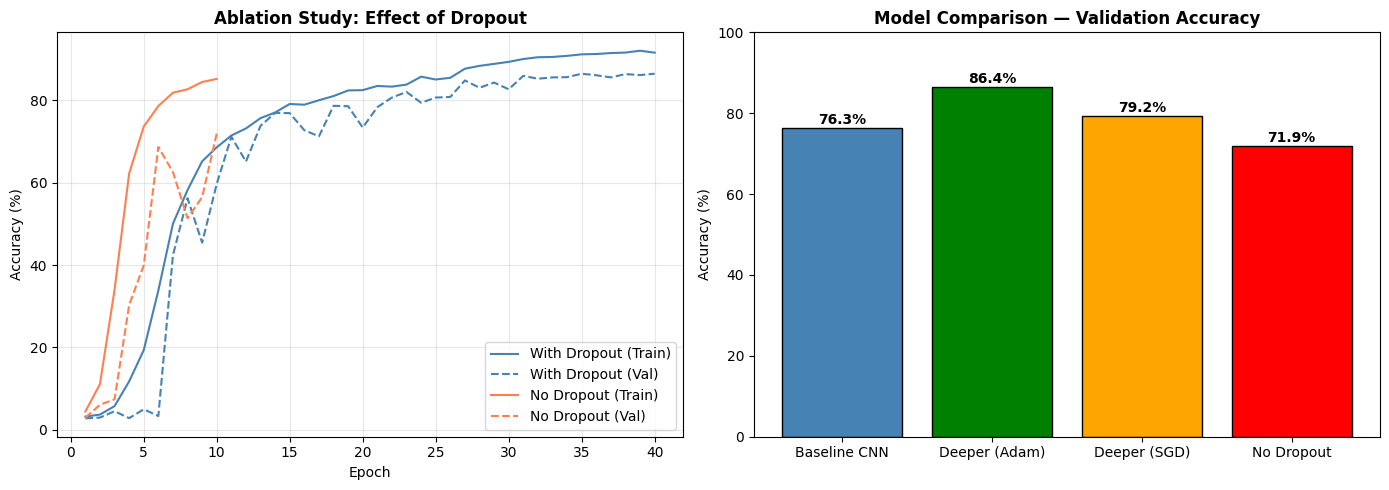


=== COMPREHENSIVE MODEL COMPARISON ===
Baseline CNN         : 76.26%
Deeper CNN (Adam)    : 86.43%
Deeper CNN (SGD)     : 79.24%
Deeper (No Dropout)  : 71.92%


In [ ]:
# ── Ablation Study Comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_ablation = range(1, len(history_ablation.history['accuracy'])+1)
epochs_deeper = range(1, len(history_deeper.history['accuracy'])+1)

# Convert all accuracy values to percentages
ax1.plot(epochs_deeper, [a*100 for a in history_deeper.history['accuracy']], label='With Dropout (Train)', color='steelblue')
ax1.plot(epochs_deeper, [a*100 for a in history_deeper.history['val_accuracy']], label='With Dropout (Val)', color='steelblue', linestyle='--')
ax1.plot(epochs_ablation, [a*100 for a in history_ablation.history['accuracy']], label='No Dropout (Train)', color='coral')
ax1.plot(epochs_ablation, [a*100 for a in history_ablation.history['val_accuracy']], label='No Dropout (Val)', color='coral', linestyle='--')
ax1.set_title('Ablation Study: Effect of Dropout', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)'); ax1.legend(); ax1.grid(True, alpha=0.3)

val_generator.reset()
_, acc_ablation = ablation_model.evaluate(val_generator, verbose=0)
models_compared = ['Baseline CNN', 'Deeper (Adam)', 'Deeper (SGD)', 'No Dropout']
accs_compared   = [val_acc*100, val_acc_d*100, val_acc_sgd*100, acc_ablation*100]
colors = ['steelblue', 'green', 'orange', 'red']
ax2.bar(models_compared, accs_compared, color=colors, edgecolor='black')
ax2.set_title('Model Comparison — Validation Accuracy', fontweight='bold')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 100)
for i, v in enumerate(accs_compared):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print('\n=== COMPREHENSIVE MODEL COMPARISON ===')
print(f'Baseline CNN         : {val_acc*100:.2f}%')
print(f'Deeper CNN (Adam)    : {val_acc_d*100:.2f}%')
print(f'Deeper CNN (SGD)     : {val_acc_sgd*100:.2f}%')
print(f'Deeper (No Dropout)  : {acc_ablation*100:.2f}%')

In [ ]:
# ===== LOAD MODELS + EVALUATE ALL =====
import os, pickle, shutil
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

LOCAL_DIR = '/content/sign_language_local'
SOURCE = '/content/drive/MyDrive/AI and Machine Learning/Assessment/Sign Language Detection-20260416T180914Z-3-001/Sign Language Detection'
if not os.path.exists(LOCAL_DIR):
    shutil.copytree(SOURCE, LOCAL_DIR)
TRAIN_DIR = f'{LOCAL_DIR}/Train'

NUM_CLASSES, IMG_SIZE, BATCH_SIZE = 38, (224, 224), 32

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_generator = val_datagen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False)

tl_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)
tl_val_gen = tl_val_datagen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False)

classes = sorted(os.listdir(TRAIN_DIR), key=lambda x: int(x))

SAVE_DIR = '/content/drive/MyDrive/AI and Machine Learning/Assessment/VisionTask Models'
baseline_model = keras.models.load_model(f'{SAVE_DIR}/baseline_cnn.keras')
deeper_model = keras.models.load_model(f'{SAVE_DIR}/deeper_cnn_adam.keras')
deeper_sgd = keras.models.load_model(f'{SAVE_DIR}/deeper_cnn_sgd.keras')
ablation_model = keras.models.load_model(f'{SAVE_DIR}/ablation_no_dropout.keras')
tl_model = keras.models.load_model(f'{SAVE_DIR}/mobilenetv2_tl.keras')

def load_hist(name):
    with open(f'{SAVE_DIR}/{name}.pkl', 'rb') as f:
        return type('obj', (), {'history': pickle.load(f)})()

history_baseline = load_hist('baseline_history')
history_deeper = load_hist('deeper_history')
history_sgd = load_hist('sgd_history')
history_ablation = load_hist('ablation_history')
history_tl_phase1 = load_hist('tl_phase1_history')
history_tl_phase2 = load_hist('tl_phase2_history')

# Hardcode times since we know them
baseline_training_time = 64.6 * 60
deeper_training_time = 90.5 * 60
sgd_training_time = 91.4 * 60
phase1_time = 17.0 * 60
phase2_time = 21.2 * 60
tl_total_time = phase1_time + phase2_time

# Evaluate all
val_generator.reset(); _, val_acc = baseline_model.evaluate(val_generator, verbose=0)
val_generator.reset(); _, val_acc_d = deeper_model.evaluate(val_generator, verbose=0)
val_generator.reset(); _, val_acc_sgd = deeper_sgd.evaluate(val_generator, verbose=0)
val_generator.reset(); _, acc_ablation = ablation_model.evaluate(val_generator, verbose=0)
tl_val_gen.reset(); _, tl_acc = tl_model.evaluate(tl_val_gen, verbose=0)

print(f'Baseline: {val_acc*100:.2f}% | Deeper Adam: {val_acc_d*100:.2f}% | SGD: {val_acc_sgd*100:.2f}%')
print(f'Ablation: {acc_ablation*100:.2f}% | TL: {tl_acc*100:.2f}%')

Found 2144 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Baseline: 76.26% | Deeper Adam: 86.43% | SGD: 79.24%
Ablation: 71.92% | TL: 91.51%


In [ ]:
# ── Data generators for Transfer Learning
# MobileNetV2 expects inputs preprocessed with preprocess_input()

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # MobileNetV2 specific preprocessing
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

tl_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)

tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)

print('Transfer learning data generators ready!')

In [ ]:
# ── Phase 1: Feature Extraction
# Load MobileNetV2 pretrained on ImageNet, FREEZE all its layers
# Only train the new Dense layers we add on top

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,    # Remove original 1000-class output layer
    weights='imagenet'    # Use weights learned from ImageNet
)

# Freeze all pretrained layers — don't change their weights
base_model.trainable = False
print(f'MobileNetV2 loaded: {len(base_model.layers)} layers, all frozen')

# Build the full model: MobileNetV2 base + our custom classification head
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)          # Pass through MobileNetV2
x = layers.GlobalAveragePooling2D()(x)          # Reduce to 1D vector
x = layers.Dense(256, activation='relu')(x)     # Our new Dense layer
x = layers.Dropout(0.4)(x)                      # Dropout for regularisation
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # Output

tl_model = keras.Model(inputs, outputs)

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded: 154 layers, all frozen


Model: "functional_198"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ── Train Phase 1: Feature Extraction

print('Phase 1: Feature Extraction — Training new layers only...')
start_time = time.time()

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=15,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

phase1_time = time.time() - start_time
print(f'Phase 1 complete! Time: {phase1_time/60:.1f} minutes')

In [ ]:
# ── Phase 2: Fine-Tuning
# Now unfreeze the last 30 layers of MobileNetV2 and let them adjust
# Use a MUCH lower learning rate to avoid destroying learned features

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Fine-tuning: {trainable_count} MobileNetV2 layers unfrozen')

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 2: Fine-Tuning — Adjusting MobileNetV2 layers...')
start_time = time.time()

history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=20,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
        PercentLogger()
    ],
    verbose=1
)

phase2_time = time.time() - start_time
tl_total_time = phase1_time + phase2_time
print(f'Phase 2 complete! Time: {phase2_time/60:.1f} minutes')
print(f'Total Transfer Learning time: {tl_total_time/60:.1f} minutes')
print(f'Final Train Accuracy: {history_tl_phase2.history["accuracy"][-1]*100:.2f}%')
print(f'Final Val Accuracy:   {history_tl_phase2.history["val_accuracy"][-1]*100:.2f}%')

In [ ]:
# ── Evaluate Transfer Learning Model

tl_val_gen.reset()
tl_loss, tl_acc = tl_model.evaluate(tl_val_gen, verbose=0)
print(f'Transfer Learning (MobileNetV2) — Validation Accuracy: {tl_acc*100:.2f}%')
print(f'Transfer Learning (MobileNetV2) — Validation Loss:     {tl_loss:.4f}')

tl_val_gen.reset()
y_pred_tl = np.argmax(tl_model.predict(tl_val_gen, verbose=1), axis=1)

print('\nClassification Report (Transfer Learning — MobileNetV2):')
print(classification_report(tl_val_gen.classes, y_pred_tl, target_names=[f'Class {c}' for c in classes]))

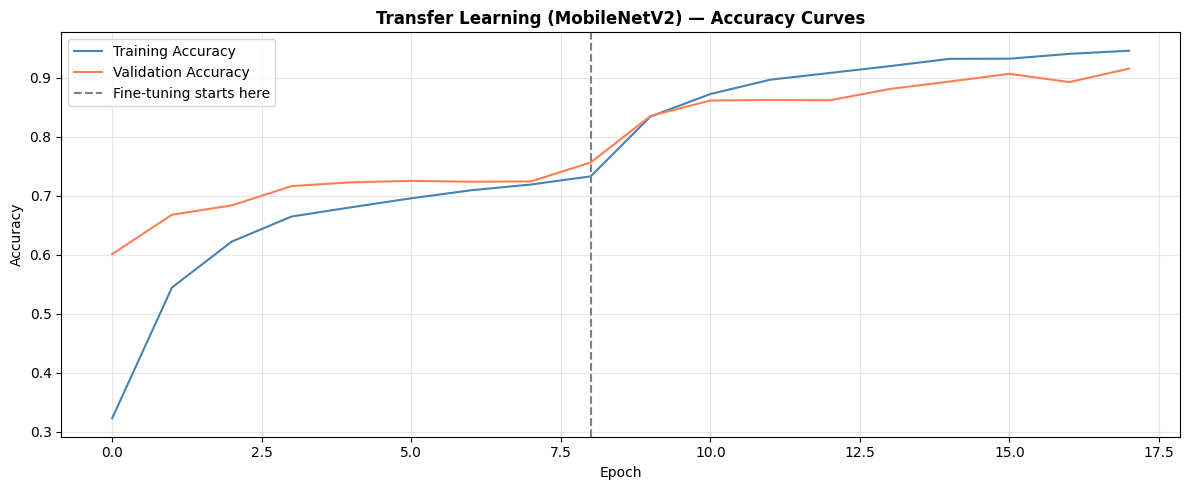

In [ ]:
# ── Transfer Learning Training Curves
# Combine Phase 1 and Phase 2 histories

combined_acc = history_tl_phase1.history['accuracy'] + history_tl_phase2.history['accuracy']
combined_val_acc = history_tl_phase1.history['val_accuracy'] + history_tl_phase2.history['val_accuracy']
phase1_end = len(history_tl_phase1.history['accuracy'])

plt.figure(figsize=(12, 5))
plt.plot(combined_acc, label='Training Accuracy', color='steelblue')
plt.plot(combined_val_acc, label='Validation Accuracy', color='coral')
plt.axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tuning starts here')
plt.title('Transfer Learning (MobileNetV2) — Accuracy Curves', fontweight='bold', fontsize=12)
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('transfer_learning_curves.png', dpi=150)
plt.show()


        FINAL MODEL COMPARISON SUMMARY
Baseline CNN (Scratch)         Accuracy: 76.26%   Training time: 64.6 min
Deeper CNN (Adam)              Accuracy: 86.43%   Training time: 90.5 min
Deeper CNN (SGD)               Accuracy: 79.24%   Training time: 91.4 min
Deeper (No Dropout)            Accuracy: 71.92%   Training time: N/A
MobileNetV2 (TL)               Accuracy: 91.51%   Training time: 38.2 min


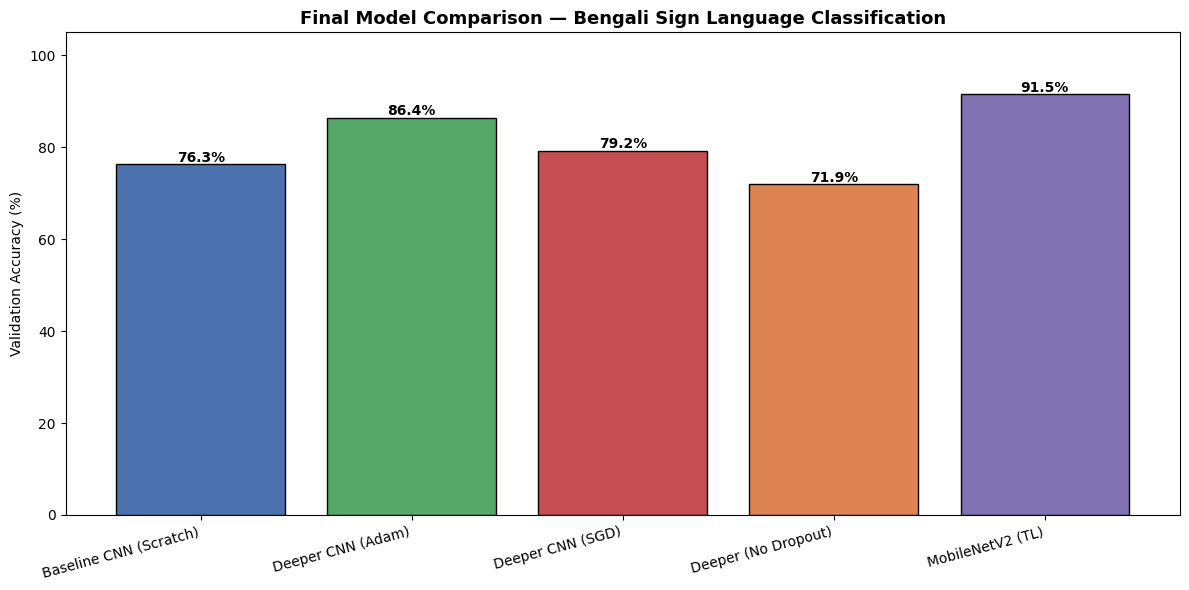

In [ ]:
# ── FINAL: All Models Comparison

print('\n' + '='*60)
print('        FINAL MODEL COMPARISON SUMMARY')
print('='*60)
results = [
    ('Baseline CNN (Scratch)', val_acc*100,    baseline_training_time/60),
    ('Deeper CNN (Adam)',      val_acc_d*100,  deeper_training_time/60),
    ('Deeper CNN (SGD)',       val_acc_sgd*100, sgd_training_time/60),
    ('Deeper (No Dropout)',   acc_ablation*100, None),
    ('MobileNetV2 (TL)',      tl_acc*100,       tl_total_time/60),
]

for name, acc, t in results:
    time_str = f'{t:.1f} min' if t else 'N/A'
    print(f'{name:<30} Accuracy: {acc:.2f}%   Training time: {time_str}')
print('='*60)

# Bar chart
names  = [r[0] for r in results]
accs   = [r[1] for r in results]
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452', '#8172B2']

plt.figure(figsize=(12, 6))
bars = plt.bar(names, accs, color=colors, edgecolor='black')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', fontweight='bold')
plt.ylim(0, 105)
plt.xticks(rotation=15, ha='right')
plt.ylabel('Validation Accuracy (%)')
plt.title('Final Model Comparison — Bengali Sign Language Classification', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()